In [ ]:

# Packages / libraries
import os #provides functions for interacting with the operating system
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, explained_variance_score, confusion_matrix, accuracy_score, classification_report, log_loss
from math import sqrt


from google.colab import files
uploaded = files.upload()

%matplotlib inline

Saving Logistic Regression Dummy Data v3.csv to Logistic Regression Dummy Data v3 (3).csv


In [ ]:
# Loading the data
raw_data = pd.read_csv("Logistic Regression Dummy Data v3.csv")

# print the shape
print(raw_data.shape)

#runs the first 5 rows
raw_data.head(5)

(1006, 14)


,Type of Account,Account History,Reason for the Loan,Loan Amount,Account Savings,Employment History,Individual Stauts,Other Loans,Security / Collateral,Age,Residence Status,Job,Completed Other loan?,Good Loan
0,No Data,critical,Learning / Edu purposes,2116.0,0-200,5-7 Years,Male,No,Property - Real Estate,47.0,House Owner,Services,No,No
1,No Data,critical,TV,2438.0,No Data,7+ Years,Male,No,Savings Account,52.0,House Owner,Skilled Labor,No,No
2,No Data,critical,Buying a New Car,2144.0,0-200,2-5 Years,Male,No,Vehicle,48.0,House Owner,Skilled Labor,No,No
3,No Data,critical,Home furniture,2073.0,No Data,2-5 Years,Married,No,Vehicle,25.0,House Owner,Skilled Labor,Yes,No
4,No Data,critical,Support for Business,1276.0,No Data,7+ Years,Male,No,No Security,59.0,Renting,Services,No,No


In [ ]:
# Checking for null values

raw_data.isnull().sum()

,0
Type of Account,2
Account History,2
Reason for the Loan,3
Loan Amount,3
Account Savings,4
Employment History,5
Individual Stauts,5
Other Loans,5
Security / Collateral,5
Age,4


In [ ]:

# Visualize the NULL observations

raw_data[raw_data['Employment History'].isnull()]

,Type of Account,Account History,Reason for the Loan,Loan Amount,Account Savings,Employment History,Individual Stauts,Other Loans,Security / Collateral,Age,Residence Status,Job,Completed Other loan?,Good Loan
686,Type C,Good,Buying a New Car,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
721,Type C,critical,Home furniture,5387.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
737,Type C,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.0,House Owner,Services,No,NaN
1005,NaN,NaN,NaN,1765.0,0-201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

# Deleting the NULL values
raw_data = raw_data.dropna(subset = ['Employment History'])

# Printing the shape
print(raw_data.shape)

# Visualize the NULL observations
raw_data.isnull().sum()

(1001, 14)


,0
Type of Account,0
Account History,0
Reason for the Loan,0
Loan Amount,0
Account Savings,0
Employment History,0
Individual Stauts,0
Other Loans,0
Security / Collateral,0
Age,0


In [ ]:
# Investigate all the elements whithin each Feature

for column in raw_data:
    unique_values = np.unique(raw_data[column])
    nr_values = len(unique_values)
    if nr_values <= 10:
        print("The number of values for feature {} is: {} -- {}".format(column, nr_values, unique_values))
    else:
        print("The number of values for feature {} is: {}".format(column, nr_values))

The number of values for feature Type of Account is: 4 -- ['No Data' 'Type A' 'Type B' 'Type C']
The number of values for feature Account History is: 3 -- ['Average (known delays)' 'Good' 'critical']
The number of values for feature Reason for the Loan is: 10 -- ['Advance Edu/training' 'All other' 'Buying a New Car' 'Buying a Used Car'
 'Home Devices' 'Home furniture' 'Learning / Edu purposes' 'Renovation'
 'Support for Business' 'TV']
The number of values for feature Loan Amount is: 911
The number of values for feature Account Savings is: 5 -- ['0-200' '1000+' '200-500' '500-1000' 'No Data']
The number of values for feature Employment History is: 5 -- ['0-2 Years' '2-5 Years' '5-7 Years' '7+ Years' 'Unemployed']
The number of values for feature Individual Stauts is: 5 -- ['Divorced' 'Female' 'Female_' 'Male' 'Married']
The number of values for feature Other Loans is: 2 -- ['No' 'Yes']
The number of values for feature Security / Collateral is: 4 -- ['No Security' 'Property - Real Estat

In [ ]:
# Deleting the outlier

raw_data = raw_data[raw_data['Age'] < 100]

raw_data.shape

(1000, 14)

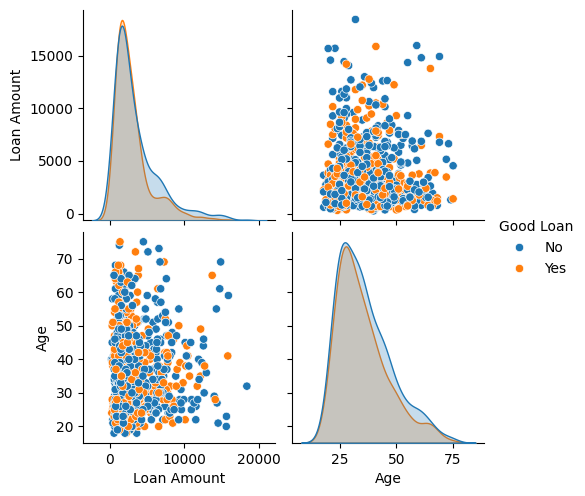

In [ ]:
g = sns.pairplot(raw_data, hue = 'Good Loan')


/tmp/ipython-input-9-106207658.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Good Loan', data = raw_data, palette = 'Set3')   # investigate distribution od dependent variable!


<Axes: xlabel='Good Loan', ylabel='count'>

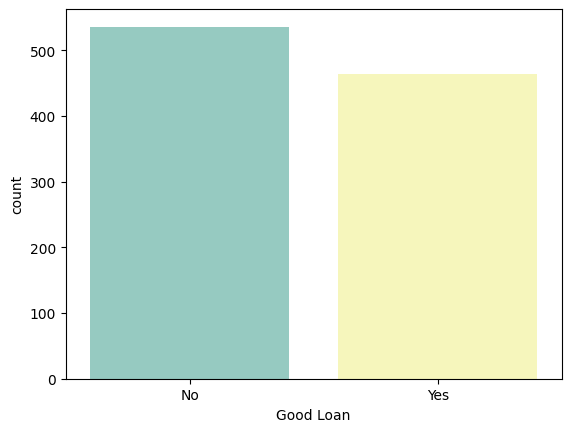

In [ ]:
sns.countplot(x = 'Good Loan', data = raw_data, palette = 'Set3')   # investigate distribution od dependent variable!

In [ ]:
# loop all columns to check how they affects by our y variable.
raw_data.columns

Index(['Type of Account', 'Account History', 'Reason for the Loan',
       'Loan Amount', 'Account Savings', 'Employment History',
       'Individual Stauts', 'Other Loans', 'Security / Collateral', 'Age',
       'Residence Status', 'Job', 'Completed Other loan?', 'Good Loan'],
      dtype='object')

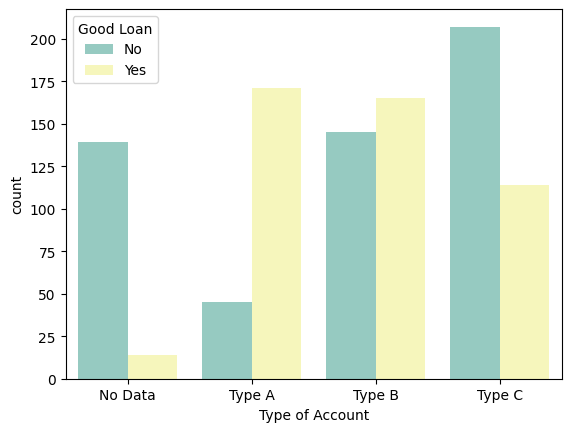

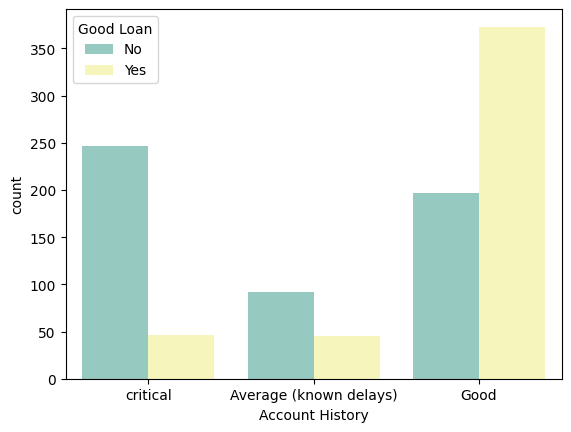

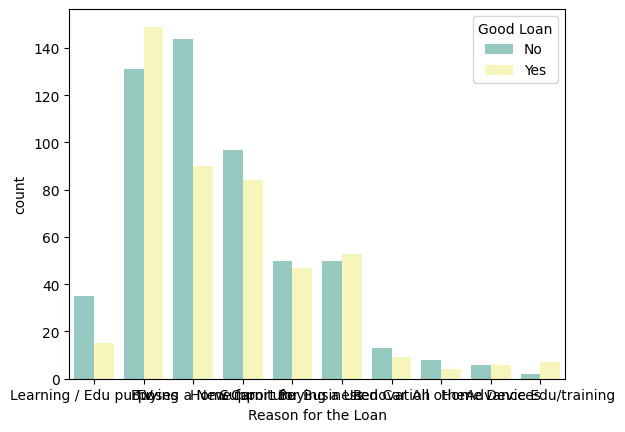

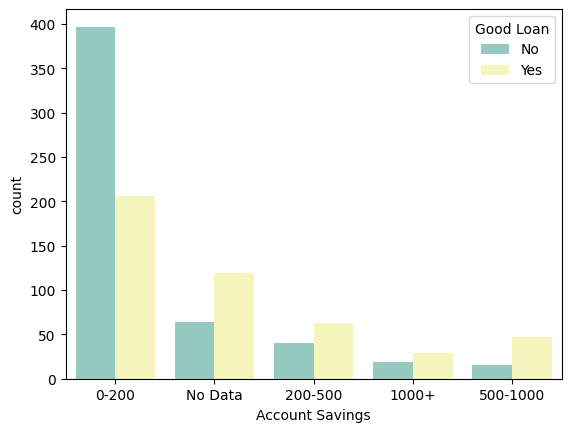

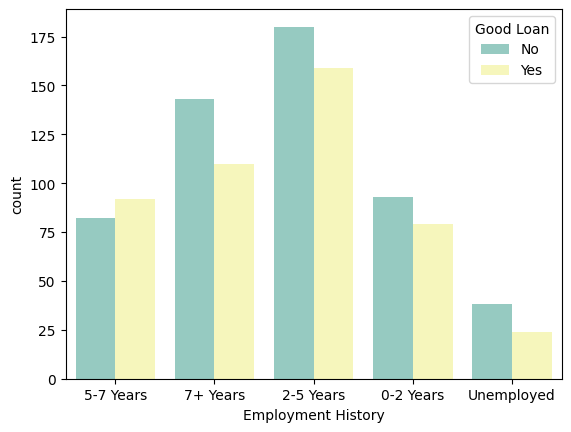

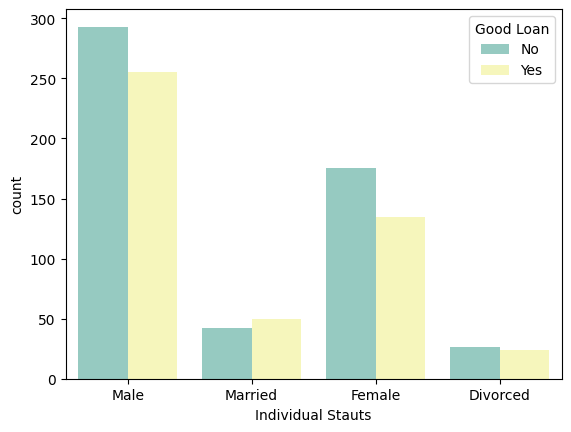

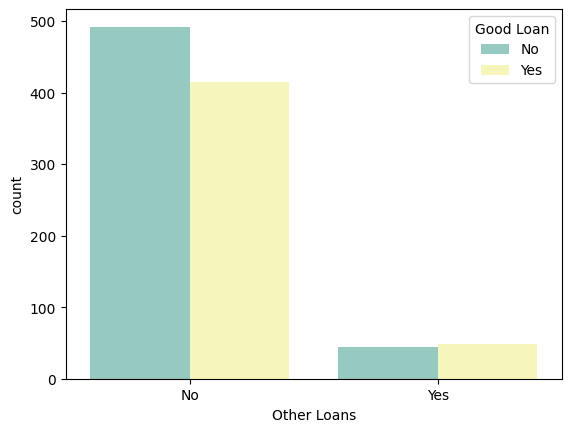

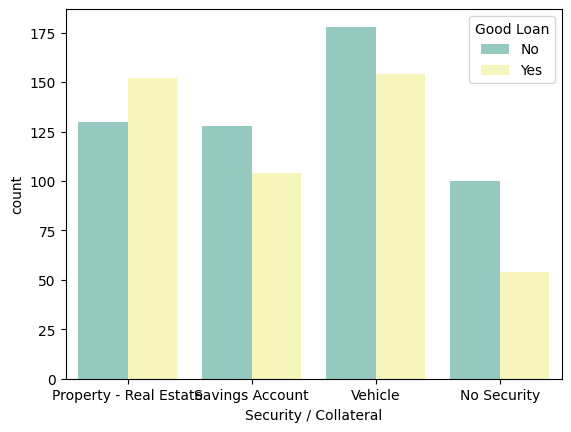

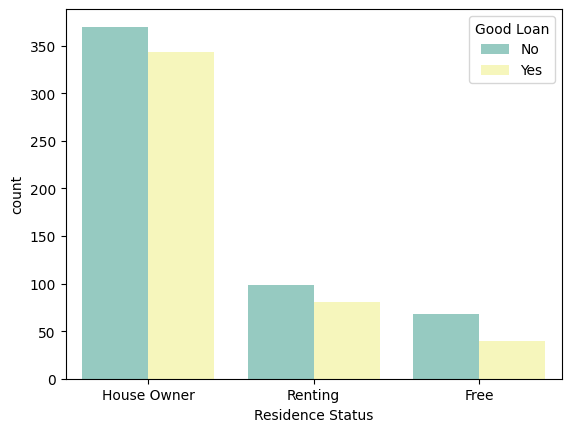

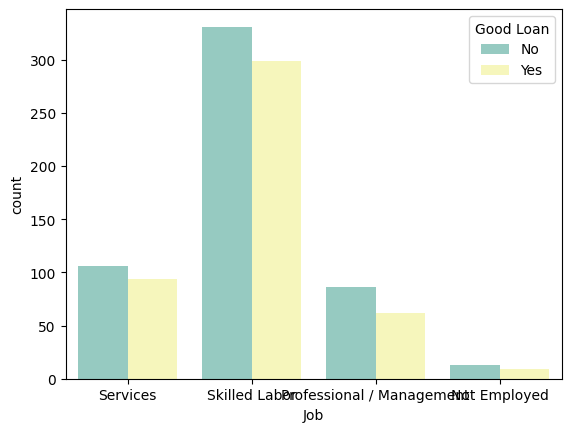

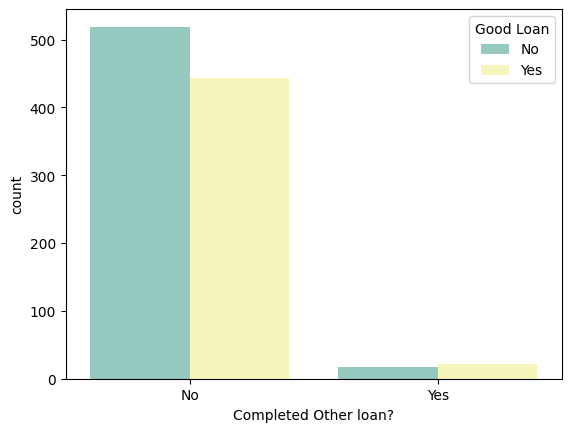

In [ ]:
fts = ['Type of Account', 'Account History', 'Reason for the Loan',
        'Account Savings', 'Employment History',
       'Individual Stauts', 'Other Loans', 'Security / Collateral',
       'Residence Status', 'Job', 'Completed Other loan?']

for f in fts:
    sns.countplot(x = f, data = raw_data, palette = 'Set3', hue = 'Good Loan')
    plt.show()

In [ ]:
new_rd = pd.get_dummies(raw_data, columns = fts,  dtype=int)
new_rd

,Loan Amount,Age,Good Loan,Type of Account_No Data,Type of Account_Type A,Type of Account_Type B,Type of Account_Type C,Account History_Average (known delays),Account History_Good,Account History_critical,...,Security / Collateral_Vehicle,Residence Status_Free,Residence Status_House Owner,Residence Status_Renting,Job_Not Employed,Job_Professional / Management,Job_Services,Job_Skilled Labor,Completed Other loan?_No,Completed Other loan?_Yes
0,2116.0,47.0,No,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,1,0
1,2438.0,52.0,No,1,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,1,0
2,2144.0,48.0,No,1,0,0,0,0,0,1,...,1,0,1,0,0,0,0,1,1,0
3,2073.0,25.0,No,1,0,0,0,0,0,1,...,1,0,1,0,0,0,0,1,0,1
4,1276.0,59.0,No,1,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,3602.0,47.0,No,0,0,0,1,1,0,0,...,0,0,1,0,0,0,1,0,1,0
1000,4473.0,35.0,No,0,0,0,1,1,0,0,...,0,0,1,0,0,0,0,1,1,0
1001,12759.0,38.0,Yes,0,0,0,1,1,0,0,...,1,0,1,0,0,1,0,0,1,0
1002,2551.0,47.0,No,0,0,0,1,1,0,0,...,1,0,1,0,0,0,1,0,1,0


In [ ]:
print(raw_data.shape)
print(new_rd.shape)

(1000, 14)
(1000, 49)


In [ ]:
new_rd['Good Loan'] = new_rd['Good Loan'].str.replace('No', '0')
new_rd['Good Loan'] = new_rd['Good Loan'].str.replace('Yes', '1')
new_rd

,Loan Amount,Age,Good Loan,Type of Account_No Data,Type of Account_Type A,Type of Account_Type B,Type of Account_Type C,Account History_Average (known delays),Account History_Good,Account History_critical,...,Security / Collateral_Vehicle,Residence Status_Free,Residence Status_House Owner,Residence Status_Renting,Job_Not Employed,Job_Professional / Management,Job_Services,Job_Skilled Labor,Completed Other loan?_No,Completed Other loan?_Yes
0,2116.0,47.0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,1,0,1,0
1,2438.0,52.0,0,1,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,1,0
2,2144.0,48.0,0,1,0,0,0,0,0,1,...,1,0,1,0,0,0,0,1,1,0
3,2073.0,25.0,0,1,0,0,0,0,0,1,...,1,0,1,0,0,0,0,1,0,1
4,1276.0,59.0,0,1,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999,3602.0,47.0,0,0,0,0,1,1,0,0,...,0,0,1,0,0,0,1,0,1,0
1000,4473.0,35.0,0,0,0,0,1,1,0,0,...,0,0,1,0,0,0,0,1,1,0
1001,12759.0,38.0,1,0,0,0,1,1,0,0,...,1,0,1,0,0,1,0,0,1,0
1002,2551.0,47.0,0,0,0,0,1,1,0,0,...,1,0,1,0,0,0,1,0,1,0


In [ ]:
# split the data into x and y ..... select the feature which affects the y variable the most.
x = new_rd.drop('Good Loan', axis = 1)
y = new_rd['Good Loan']

y = y.astype('int')

print(x.shape)
print(y.shape)

(1000, 48)
(1000,)


In [ ]:
dt = DecisionTreeClassifier(random_state = 42,  criterion = 'entropy', max_depth = 10 )
dt.fit(x, y)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

In [ ]:
# running Feature importance

fi_col = []
fi = []
for i, column in enumerate(new_rd.drop('Good Loan', axis = 1)):   # we dropped GoolLoan from columns in enumerate !
  print('The feature importance for {} is : {}'.format(column, dt.feature_importances_[i]))
  fi_col.append(column)
  fi.append(dt.feature_importances_[i])

The feature importance for Loan Amount is : 0.1279077119700288
The feature importance for Age is : 0.08076837315098834
The feature importance for Type of Account_No Data is : 0.054137849056979465
The feature importance for Type of Account_Type A is : 0.0496422863210934
The feature importance for Type of Account_Type B is : 0.014528271579516073
The feature importance for Type of Account_Type C is : 0.012121444510867734
The feature importance for Account History_Average (known delays) is : 0.0
The feature importance for Account History_Good is : 0.19096896730100418
The feature importance for Account History_critical is : 0.0
The feature importance for Reason for the Loan_Advance Edu/training is : 0.0
The feature importance for Reason for the Loan_All other is : 0.0
The feature importance for Reason for the Loan_Buying a New Car is : 0.009480850424639461
The feature importance for Reason for the Loan_Buying a Used Car is : 0.006561476722880578
The feature importance for Reason for the Loa

In [ ]:
fi_col
fi
# Creating set
fi_df = zip(fi_col, fi)
fi_df
# applying order
fi_df = pd.DataFrame(fi_df, columns = ['Feature', 'Feature Importance'])

fi_df.sort_values(by = 'Feature Importance', ascending = False).reset_index(drop = True)

# Columns to keeps
colulu = fi_df['Feature'][0 : 40]
fi_df

,Feature,Feature Importance
0,Loan Amount,0.127908
1,Age,0.080768
2,Type of Account_No Data,0.054138
3,Type of Account_Type A,0.049642
4,Type of Account_Type B,0.014528
5,Type of Account_Type C,0.012121
6,Account History_Average (known delays),0.000000
7,Account History_Good,0.190969
8,Account History_critical,0.000000
9,Reason for the Loan_Advance Edu/training,0.000000


In [ ]:
print(new_rd.shape)
print(new_rd[colulu].shape)

(1000, 49)
(1000, 40)


In [ ]:
#splitting datat into x ad y

x = new_rd[colulu].values
x

y = new_rd['Good Loan']
y = y.astype('int')
y

print(x.shape)
print(y.shape)

(1000, 40)
(1000,)


In [ ]:
# train_test_split func

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, test_size = 0.1, random_state = 42)

print(x_train.shape)
print(x_test.shape)
print(x_valid.shape)

print(y_train.shape)
print(y_test.shape)
print(y_valid.shape)

(720, 40)
(200, 40)
(80, 40)
(720,)
(200,)
(80,)


/tmp/ipython-input-21-1389128831.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x = y_valid, palette = 'Set3')


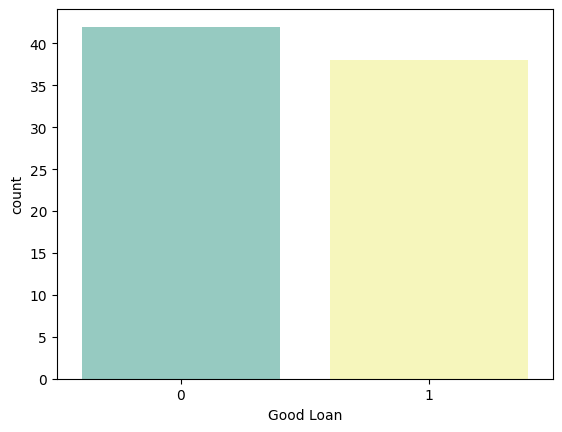

In [ ]:
# investigate the dist of all ys

ax = sns.countplot(x = y_valid, palette = 'Set3')

In [ ]:
#  Logistic regression

# in this we predict a binary classification 0 or 1 .
# we transform the linear regression line into a logistic regression curve.

# training my model

logreg = LogisticRegression(random_state=10, solver = 'lbfgs')

logreg.fit(x_train, y_train)



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=10)

In [ ]:
logreg.predict(x_train)

y_pred = logreg.predict(x_train)

# pred_proba on Training set
pred_proba = logreg.predict_proba(x_train)
# pred_proba on testing dataset
pred_proba_test = logreg.predict_proba(x_test)
# coef
logreg.coef_.shape


# score - Return the Mean Accuracy on the given test data and labels now!

(1, 40)

In [ ]:
# accuracy on training set.
# on training Dataset
print('The training accuracy is : ',logreg.score(x_train, y_train))

# on Test Dataset
print('The testing accuracy is : ',logreg.score(x_test, y_test))

# Classification report :

print(classification_report(y_train, y_pred))


The training accuracy is :  0.7736111111111111
The testing accuracy is :  0.795
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       388
           1       0.76      0.73      0.75       332

    accuracy                           0.77       720
   macro avg       0.77      0.77      0.77       720
weighted avg       0.77      0.77      0.77       720



In [ ]:
# Confusion Matrix function
def plot_confusion_matrix(cm, classes=None, title='Confusion matrix'):
    """Plots a confusion matrix."""
    if classes is not None:
        sns.heatmap(cm, xticklabels=classes, yticklabels=classes, vmin=0., vmax=1., annot=True, annot_kws={'size': 50})
    else:
        sns.heatmap(cm, vmin=0., vmax=1.)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')


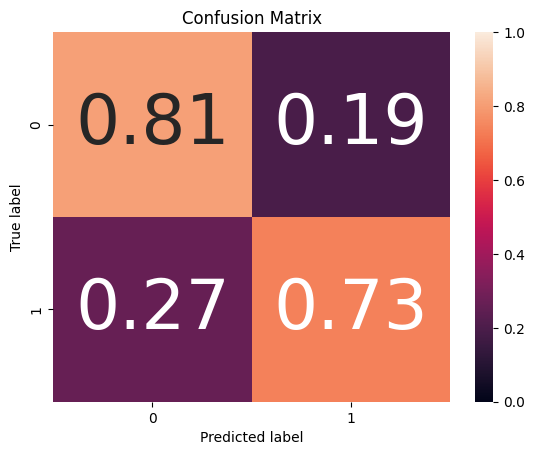

In [ ]:
cm = confusion_matrix(y_train, y_pred)
cm_norm = cm / cm.sum(axis = 1).reshape(-1, 1)

plot_confusion_matrix(cm_norm, classes = logreg.classes_, title = 'Confusion Matrix')

In [ ]:
cm.sum(axis=1)
cm_norm

array([[0.80670103, 0.19329897],
       [0.26506024, 0.73493976]])

In [ ]:
# calculating positve FP FN TP and TN

FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TP = np.diag(cm)
TN = cm.sum() - (FP + FN + TP)

# Senstivity. hit rate, recall, or true positive rate

tpr = TP / (TP + FN)
print('The true positive rate is :', tpr)
# Specificity or true negative rate


# Precision or positive predictive value

ppv = TP / (TP + FP)
print('The positive predictive value is :', ppv)


# False positive rate or false alarm rate

fpr = FP / (FP + TN)
print('The false positive rate is :', fpr)

# False negative rate or Miss Rate

fnr = FN / (FN + TP)
print('The false negative rate is :', fnr)

# classification error



# Total averages :
print("")
print('Th Avg tpr is ', tpr.sum()/2)
print('Th Avg positive prediction rate is ', ppv.sum()/2)
print('Th Avg False positive rate is ', fpr.sum()/2)
print('Th Avg False Negitive prediction rate is ', fnr.sum()/2)


The true positive rate is : [0.80670103 0.73493976]
The positive predictive value is : [0.78054863 0.76489028]
The false positive rate is : [0.26506024 0.19329897]
The false negative rate is : [0.19329897 0.26506024]

Th Avg tpr is  0.7708203949819898
Th Avg positive prediction rate is  0.7727194552802945
Th Avg False positive rate is  0.2291796050180102
Th Avg False Negitive prediction rate is  0.2291796050180102


In [ ]:
# Running log loss on training
print('The log loss on training Dataset is :', log_loss(y_train, pred_proba))

# Running log loss on testing dataset
print('The log loss on testing Dataset is :', log_loss(y_test, pred_proba_test))



The log loss on training Dataset is : 0.4490686493662055
The log loss on testing Dataset is : 0.4575157461195657


In [ ]:
# Hyper Parameter Tuning!
# mainly to prevent Overffitng and we set penalty, regularization and max_iter.

# looping over the parameters manually instead of using GridSearchCV for better understanding!

clist = np.geomspace(1e-5, 1e5, num = 20)
CA = []

Lloss = []

for c in clist:
  logreg2 = LogisticRegression(C = c, random_state = 10, solver = 'lbfgs', max_iter = 200)
  logreg2.fit(x_train, y_train)
  score = logreg2.score(x_test, y_test)
  CA.append(score)
  print('the CA of c parameter {} is {}:'.format(c, score))
  loss = log_loss(y_test, logreg2.predict_proba(x_test))
  Lloss.append(loss)
  print('the log loss of c parameter {} is {}:'.format(c, loss))
  print("")

the CA of c parameter 1e-05 is 0.515:
the log loss of c parameter 1e-05 is 0.693072441918774:

the CA of c parameter 3.359818286283781e-05 is 0.495:
the log loss of c parameter 3.359818286283781e-05 is 0.6925857983546669:

the CA of c parameter 0.00011288378916846884 is 0.52:
the log loss of c parameter 0.00011288378916846884 is 0.6907721189392615:

the CA of c parameter 0.000379269019073225 is 0.555:
the log loss of c parameter 0.000379269019073225 is 0.6837282838691406:

the CA of c parameter 0.0012742749857031334 is 0.65:
the log loss of c parameter 0.0012742749857031334 is 0.661735239910474:

the CA of c parameter 0.004281332398719391 is 0.73:
the log loss of c parameter 0.004281332398719391 is 0.6103368011186878:



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


the CA of c parameter 0.01438449888287663 is 0.78:
the log loss of c parameter 0.01438449888287663 is 0.5379681697439033:



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


the CA of c parameter 0.04832930238571752 is 0.825:
the log loss of c parameter 0.04832930238571752 is 0.4839608276083653:



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

the CA of c parameter 0.1623776739188721 is 0.8:
the log loss of c parameter 0.1623776739188721 is 0.4611245937616912:

the CA of c parameter 0.5455594781168515 is 0.795:
the log loss of c parameter 0.5455594781168515 is 0.45538985941076576:

the CA of c parameter 1.8329807108324339 is 0.79:
the log loss of c parameter 1.8329807108324339 is 0.45449487309722214:

the CA of c parameter 6.1584821106602545 is 0.795:
the log loss of c parameter 6.1584821106602545 is 0.45793478634212165:



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

the CA of c parameter 20.6913808111479 is 0.79:
the log loss of c parameter 20.6913808111479 is 0.4544611529089323:

the CA of c parameter 69.51927961775606 is 0.79:
the log loss of c parameter 69.51927961775606 is 0.4543531891323744:

the CA of c parameter 233.57214690901213 is 0.795:
the log loss of c parameter 233.57214690901213 is 0.45447278709232086:

the CA of c parameter 784.7599703514607 is 0.795:
the log loss of c parameter 784.7599703514607 is 0.459214374485205:

the CA of c parameter 2636.6508987303555 is 0.795:
the log loss of c parameter 2636.6508987303555 is 0.45769441693033414:

the CA of c parameter 8858.667904100832 is 0.79:
the log loss of c parameter 8858.667904100832 is 0.45455314535284175:

the CA of c parameter 29763.51441631313 is 0.795:
the log loss of c parameter 29763.51441631313 is 0.4533974563739241:

the CA of c parameter 100000.0 is 0.79:
the log loss of c parameter 100000.0 is 0.45219813549782956:



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
CA2 = np.array(CA).reshape(20,)
Lloss2 = np.array(Lloss).reshape(20,)

outcomes = zip(clist, CA2, Lloss2)
outcomes = pd.DataFrame(outcomes, columns = ['clist', 'CA2', 'Lloss2'])
outcomes


outcomes.sort_values("Lloss2", ascending = True)

,clist,CA2,Lloss2
19,100000.000000,0.790,0.452198
18,29763.514416,0.795,0.453397
13,69.519280,0.790,0.454353
12,20.691381,0.790,0.454461
14,233.572147,0.795,0.454473
10,1.832981,0.790,0.454495
17,8858.667904,0.790,0.454553
9,0.545559,0.795,0.455390
16,2636.650899,0.795,0.457694
11,6.158482,0.795,0.457935


In [ ]:
# Finding the vest c - parameter by LogisticRegressionCV

kf = KFold(n_splits = 3, shuffle = True, random_state = 0)
logreg3 = LogisticRegressionCV(cv = kf, random_state = 15, Cs = clist, max_iter = 100)
logreg3.fit(x_train, y_train)
print('The best C parameter is :', logreg3.score(x_test, y_test))
pred_proba_t = logreg3.predict_proba(x_test)
print('The log loss on testing Dataset is :', log_loss(y_test, pred_proba_t))

# optimal c-para,eter
print('The optimal c parameter is :', logreg3.C_)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

The best C parameter is : 0.8
The log loss on testing Dataset is : 0.46132876792091587
The optimal c parameter is : [0.16237767]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Training a dummy classifier
dummy_clf = DummyClassifier(strategy = 'most_frequent')
dummy_clf.fit(x_train, y_train)
score = dummy_clf.score(x_test, y_test)
print('The accuracy of the dummy classifier is :', score)
pred = dummy_clf.predict_proba(x_test)
loss = log_loss(y_test, pred)
print('The log loss of the dummy classifier is :', loss)



The accuracy of the dummy classifier is : 0.53
The log loss of the dummy classifier is : 16.94051709288506


In [ ]:
# Final Model

logreg3 = LogisticRegression(C =100000.000000 , random_state = 10, solver = 'lbfgs')
logreg3.fit(x_train, y_train)
score = logreg3.score(x_valid, y_valid)

pred_proba_t = logreg3.predict_proba(x_valid)
loss = log_loss(y_valid, logreg3.predict_proba(x_valid))
print('The log loss of the dummy classifier is :', loss)

print('The accuracy of the dummy classifier is :', score)


The log loss of the dummy classifier is : 0.5765466353111711
The accuracy of the dummy classifier is : 0.7125


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
